# Assignment 4: Optimization with Parallelization
Group 15

- NG, Cheuk Nam (cnng@kth.se)
- WONG, Chun Him (chwon@kth.se)

# Exercise 1: Simulating Wildfire Spread Using Monte Carlo in Parallel

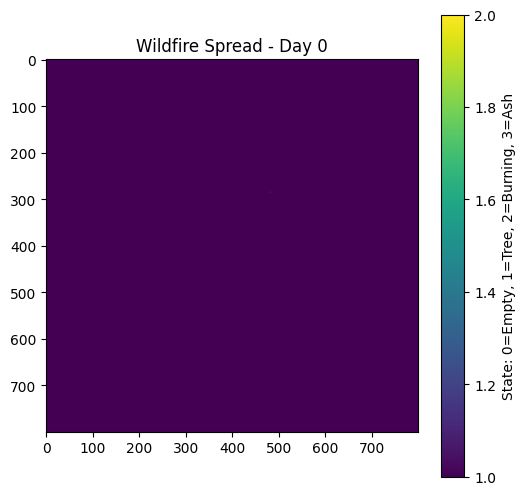

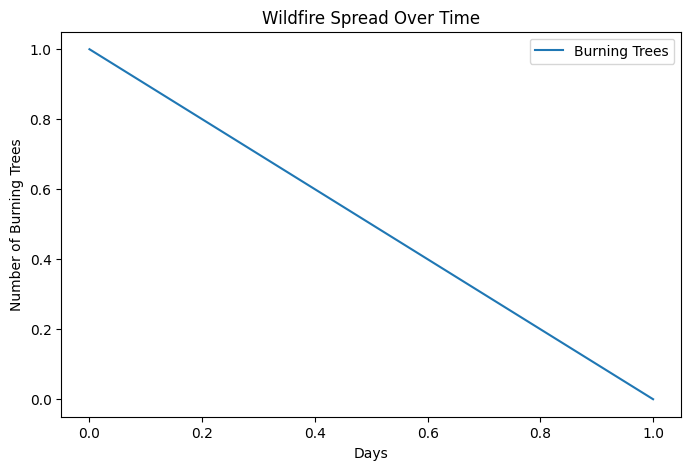

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Constants
GRID_SIZE = 800  # 800x800 forest grid
FIRE_SPREAD_PROB = 0.3  # Probability that fire spreads to a neighboring tree
BURN_TIME = 3  # Time before a tree turns into ash
DAYS = 60  # Maximum simulation time

# State definitions
EMPTY = 0    # No tree
TREE = 1     # Healthy tree 
BURNING = 2  # Burning tree 
ASH = 3      # Burned tree 

def initialize_forest():
    """Creates a forest grid with all trees and ignites one random tree."""
    forest = np.ones((GRID_SIZE, GRID_SIZE), dtype=int)  # All trees
    burn_time = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)  # Tracks how long a tree burns
    
    # Ignite a random tree
    x, y = random.randint(0, GRID_SIZE-1), random.randint(0, GRID_SIZE-1)
    forest[x, y] = BURNING
    burn_time[x, y] = 1  # Fire starts burning
    
    return forest, burn_time

def get_neighbors(x, y):
    """Returns the neighboring coordinates of a cell in the grid."""
    neighbors = []
    for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:  # Up, Down, Left, Right
        nx, ny = x + dx, y + dy
        if 0 <= nx < GRID_SIZE and 0 <= ny < GRID_SIZE:
            neighbors.append((nx, ny))
    return neighbors

def simulate_wildfire():
    """Simulates wildfire spread over time."""
    forest, burn_time = initialize_forest()
    
    fire_spread = []  # Track number of burning trees each day
    
    for day in range(DAYS):
        new_forest = forest.copy()
        
        for x in range(GRID_SIZE):
            for y in range(GRID_SIZE):
                if forest[x, y] == BURNING:
                    burn_time[x, y] += 1  # Increase burn time
                    
                    # If burn time exceeds threshold, turn to ash
                    if burn_time[x, y] >= BURN_TIME:
                        new_forest[x, y] = ASH
                    
                    # Spread fire to neighbors
                    for nx, ny in get_neighbors(x, y):
                        if forest[nx, ny] == TREE and random.random() < FIRE_SPREAD_PROB:
                            new_forest[nx, ny] = BURNING
                            burn_time[nx, ny] = 1
        
        forest = new_forest.copy()
        fire_spread.append(np.sum(forest == BURNING))
        
        if np.sum(forest == BURNING) == 0:  # Stop if no more fire
            break
        
        # Plot grid every 5 days
        if day % 5 == 0 or day == DAYS - 1:
            plt.figure(figsize=(6, 6))
            plt.imshow(forest, cmap='viridis', origin='upper')
            plt.title(f"Wildfire Spread - Day {day}")
            plt.colorbar(label="State: 0=Empty, 1=Tree, 2=Burning, 3=Ash")
            plt.show()
    
    return fire_spread

# Run simulation
fire_spread_over_time = simulate_wildfire()

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(range(len(fire_spread_over_time)), fire_spread_over_time, label="Burning Trees")
plt.xlabel("Days")
plt.ylabel("Number of Burning Trees")
plt.title("Wildfire Spread Over Time")
plt.legend()
plt.show()

## Task 1.1: Parallelization with Multiprocessing

wildfire_sim_worker.py

In [8]:
import numpy as np
import random

# Constants (must match notebook)
GRID_SIZE = 800
FIRE_SPREAD_PROB = 0.3
BURN_TIME = 3
DAYS = 60
EMPTY, TREE, BURNING, ASH = 0, 1, 2, 3


def initialize_forest():
    forest = np.ones((GRID_SIZE, GRID_SIZE), dtype=int)
    burn_time = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
    x, y = random.randint(0, GRID_SIZE - 1), random.randint(0, GRID_SIZE - 1)
    forest[x, y] = BURNING
    burn_time[x, y] = 1
    return forest, burn_time


def get_neighbors(x, y):
    neighbors = []
    for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        nx, ny = x + dx, y + dy
        if 0 <= nx < GRID_SIZE and 0 <= ny < GRID_SIZE:
            neighbors.append((nx, ny))
    return neighbors


def run_one_simulation(_):
    """One wildfire run (no plotting). Returns list of burning-tree counts per day."""
    forest, burn_time = initialize_forest()
    fire_spread = []
    for day in range(DAYS):
        new_forest = forest.copy()
        for x in range(GRID_SIZE):
            for y in range(GRID_SIZE):
                if forest[x, y] == BURNING:
                    burn_time[x, y] += 1
                    if burn_time[x, y] >= BURN_TIME:
                        new_forest[x, y] = ASH
                    for nx, ny in get_neighbors(x, y):
                        if forest[nx, ny] == TREE and random.random() < FIRE_SPREAD_PROB:
                            new_forest[nx, ny] = BURNING
                            burn_time[nx, ny] = 1
        forest = new_forest.copy()
        fire_spread.append(int(np.sum(forest == BURNING)))
        if np.sum(forest == BURNING) == 0:
            break
    return fire_spread


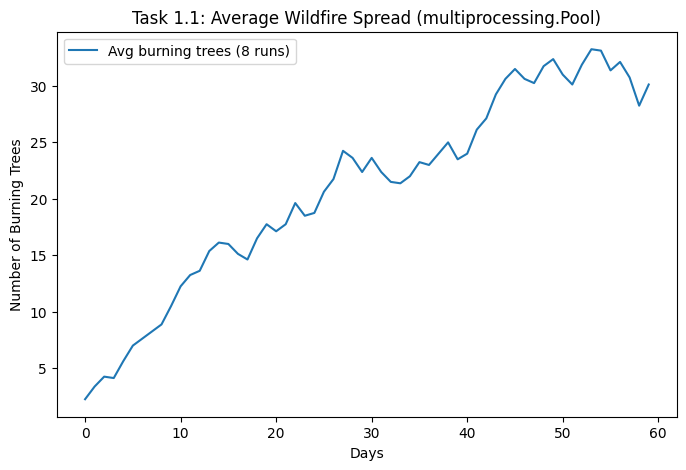

In [9]:
from multiprocessing import Pool, cpu_count
from wildfire_sim_worker import run_one_simulation  # worker in .py so Pool workers can import it

N_RUNS = 8  # number of independent simulations
n_workers = min(N_RUNS, cpu_count())

with Pool(processes=n_workers) as pool:
    results = pool.map(run_one_simulation, range(N_RUNS))

# Aggregate: average fire spread over time (pad shorter runs with 0)
max_len = max(len(r) for r in results)
padded = [np.array(r + [0] * (max_len - len(r)), dtype=float) for r in results]
avg_fire_spread = np.mean(padded, axis=0)

# Plot average fire spread
plt.figure(figsize=(8, 5))
plt.plot(range(len(avg_fire_spread)), avg_fire_spread, label="Avg burning trees ({} runs)".format(N_RUNS))
plt.xlabel("Days")
plt.ylabel("Number of Burning Trees")
plt.title("Task 1.1: Average Wildfire Spread (multiprocessing.Pool)")
plt.legend()
plt.show()


## Task1.2: Parallelization with Dask

Dask Dashboard: http://127.0.0.1:8787/status
→ Open this URL in your browser BEFORE the long computation, then go to the 'Task Stream' tab.
Computation submitted. Open the dashboard link above → 'Task Stream' or 'Tasks' tab to see the 8 simulations.


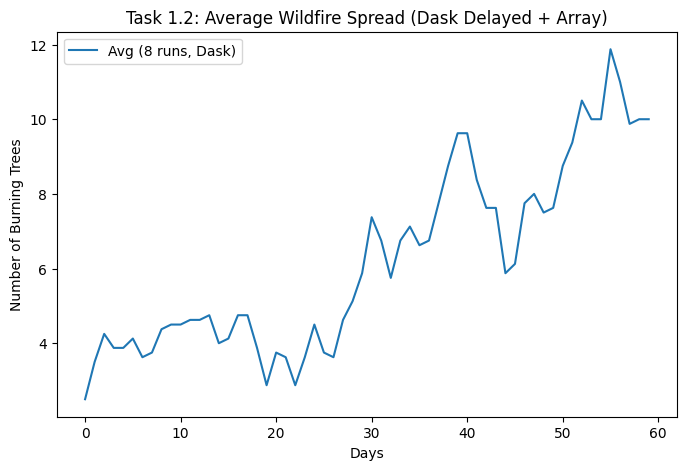

In [10]:
# Task 1.2: Parallelization with Dask (Delayed + Dask Array + distributed Client + Dashboard)
import dask
from dask import delayed
import dask.array as da
from dask.distributed import Client

# Start distributed client. Dashboard runs on localhost:8787 by default.
client = Client()
# Use this cluster for all Dask work (so the dashboard shows activity)
import dask.config
dask.config.set(scheduler=client)
print("Dask Dashboard:", client.dashboard_link)
print("→ Open this URL in your browser BEFORE the long computation, then go to the 'Task Stream' tab.")

# Wrapper: one simulation returning a fixed-length array (DAYS,) for Dask Array aggregation
def run_one_simulation_padded(_):
    from wildfire_sim_worker import run_one_simulation, DAYS
    import numpy as np
    r = run_one_simulation(_)
    return np.array(r + [0] * (DAYS - len(r)), dtype=np.float64)

N_RUNS = 8

# 1. Convert to Dask Delayed: each call is a lazy task
delayed_sims = [delayed(run_one_simulation_padded)(i) for i in range(N_RUNS)]

# 2. Convert results into a Dask Array (each delayed returns shape (DAYS,))
dask_arrays = [da.from_delayed(d, shape=(DAYS,), dtype=np.float64) for d in delayed_sims]
stacked = da.stack(dask_arrays)  # shape (N_RUNS, DAYS)

# 3. Aggregate with Dask Array: mean over runs, then compute
# Submit via client.compute() so tasks definitely run on the cluster and show on the dashboard
future = client.compute(da.mean(stacked, axis=0))
print("Computation submitted. Open the dashboard link above → 'Task Stream' or 'Tasks' tab to see the 8 simulations.")
avg_fire_spread = future.result()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(range(len(avg_fire_spread)), avg_fire_spread, label="Avg ({} runs, Dask)".format(N_RUNS))
plt.xlabel("Days")
plt.ylabel("Number of Burning Trees")
plt.title("Task 1.2: Average Wildfire Spread (Dask Delayed + Array)")
plt.legend()
plt.show()

client.close()

Dask Dashboard
![](asm4_task1.2.png)

## Task1.3: Performance Comparison

In [ ]:
import time
import numpy as np
from multiprocessing import Pool, cpu_count
from wildfire_sim_worker import run_one_simulation, DAYS

N_RUNS = 8
n_repeats = 2


def run_serial():
    results = [run_one_simulation(i) for i in range(N_RUNS)]
    return np.array([r + [0] * (DAYS - len(r)) for r in results], dtype=float).mean(axis=0)


def run_multiprocessing():
    n_workers = min(N_RUNS, cpu_count())
    with Pool(processes=n_workers) as pool:
        results = pool.map(run_one_simulation, range(N_RUNS))
    padded = [np.array(r + [0] * (DAYS - len(r)), dtype=float) for r in results]
    return np.mean(padded, axis=0)


def run_dask(n_workers=4, use_processes=True):
    try:
        from dask import delayed
        import dask.array as da
        from dask.distributed import Client, LocalCluster
    except ImportError:
        raise ImportError("Install dask and distributed: pip install dask distributed")

    def padded(_):
        from wildfire_sim_worker import run_one_simulation, DAYS
        import numpy as np
        r = run_one_simulation(_)
        return np.array(r + [0] * (DAYS - len(r)), dtype=np.float64)

    cluster = LocalCluster(processes=use_processes, n_workers=n_workers)
    client = Client(cluster)
    delayed_sims = [delayed(padded)(i) for i in range(N_RUNS)]
    dask_arrays = [da.from_delayed(d, shape=(DAYS,), dtype=np.float64) for d in delayed_sims]
    stacked = da.stack(dask_arrays)
    result = da.mean(stacked, axis=0).compute(scheduler=client)
    client.close()
    return result


def main():
    print("=" * 60)
    print("Task 1.3: Performance comparison (run outside Jupyter)")
    print("N_RUNS =", N_RUNS, "| n_repeats =", n_repeats)
    print("=" * 60)

    times = {}
    for name, fn in [
        ("Serial", run_serial),
        ("Multiprocessing", run_multiprocessing),
        ("Dask (4 workers)", lambda: run_dask(4)),
    ]:
        t_list = []
        for _ in range(n_repeats):
            t0 = time.perf_counter()
            fn()
            t_list.append(time.perf_counter() - t0)
        times[name] = min(t_list)
        print(f"{name}: {times[name]:.2f} s (min of {n_repeats} runs)")

    print("\n--> Fastest:", min(times, key=times.get))


if __name__ == "__main__":
    main()



![](asm4_task1.3.png)

### Task 1.3 — Answers

1. **Which version is the fastest?**  
   According to the result above, **Multiprocessing** is fastest (parallel), and **Serial** is slowest (one core).

2. **How well does Dask scale with different numbers of workers?**  
   Time typically decreases as the number of workers increases (e.g. 1 → 2 → 4 → 8), up to a point where communication and overhead limit further speedup.
3. **How does chunk size affect performance?**  
   Fewer, larger tasks reduce scheduling overhead but can leave workers idle (worse load balance); more, smaller tasks improve load balance but add overhead. The best choice depends on run time per task and cluster size.

## Task 1.4: Visualization with ParaView and VTK

In [ ]:
import os
from wildfire_sim_worker import run_simulation_with_grids
from vtk_export import export_wildfire_to_vtk

VTK_GRID_SIZE = 100
VTK_MAX_DAYS = 40
OUT_DIR = "vtk_output"

grids = run_simulation_with_grids(grid_size=VTK_GRID_SIZE, max_days=VTK_MAX_DAYS)
paths = export_wildfire_to_vtk(grids, out_dir=OUT_DIR, prefix="forest")
print(f"Exported {len(paths)} VTK files to {OUT_DIR}/")
print(f"Files: {paths[0]} ... {paths[-1]}")
print("State: 1=Tree, 2=Burning, 3=Ash")

Exported 40 VTK files to vtk_output/
Files: vtk_output/forest_00000.vtk ... vtk_output/forest_00039.vtk
State: 1=Tree, 2=Burning, 3=Ash


### Snapshots of animation
![](asm4_task1.4_middle.png)
![](asm4_task1.4_finish.png)

# Bonus Exercise

## Serial Implementation

Time Step 0: Ocean currents updated.
Time Step 10: Ocean currents updated.
Time Step 20: Ocean currents updated.
Time Step 30: Ocean currents updated.
Time Step 40: Ocean currents updated.
Time Step 50: Ocean currents updated.
Time Step 60: Ocean currents updated.
Time Step 70: Ocean currents updated.
Time Step 80: Ocean currents updated.
Time Step 90: Ocean currents updated.
Time Step 99: Ocean currents updated.


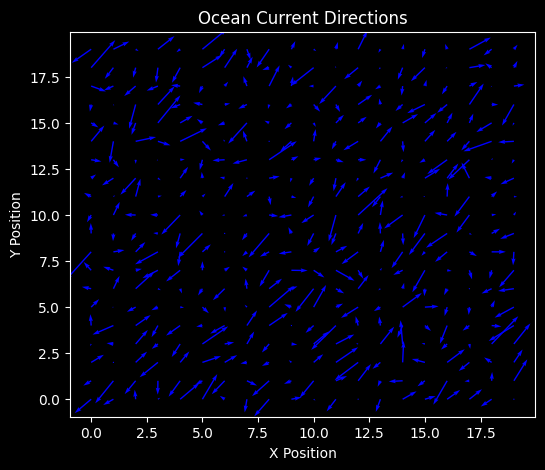

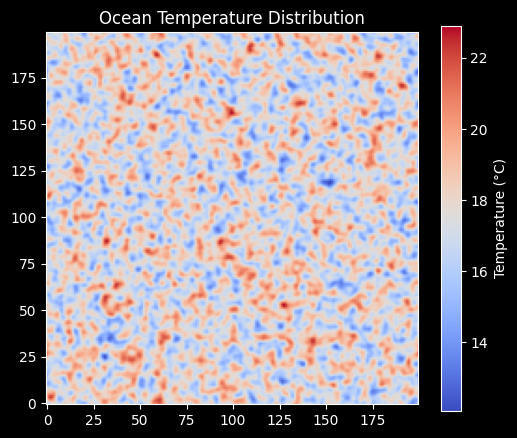

Simulation complete.


In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Grid size
grid_size = 200
TIME_STEPS = 100

# Initialize temperature field (random values between 5C and 30C)
temperature = np.random.uniform(5, 30, size=(grid_size, grid_size))

# Initialize velocity fields (u: x-direction, v: y-direction)
u_velocity = np.random.uniform(-1, 1, size=(grid_size, grid_size))
v_velocity = np.random.uniform(-1, 1, size=(grid_size, grid_size))

# Initialize wind influence (adds turbulence)
wind = np.random.uniform(-0.5, 0.5, size=(grid_size, grid_size))

def laplacian(field):
    """Computes the discrete Laplacian of a 2D field using finite differences."""
    lap = (
            np.roll(field, shift=1, axis=0) +
            np.roll(field, shift=-1, axis=0) +
            np.roll(field, shift=1, axis=1) +
            np.roll(field, shift=-1, axis=1) -
            4 * field
    )
    return lap

def update_ocean(u, v, temperature, wind, alpha=0.1, beta=0.02):
    """Updates ocean velocity and temperature fields using a simplified flow model."""
    u_new = u + alpha * laplacian(u) + beta * wind
    v_new = v + alpha * laplacian(v) + beta * wind
    temperature_new = temperature + 0.01 * laplacian(temperature)  # Small diffusion
    return u_new, v_new, temperature_new

# Run the simulation
for t in range(TIME_STEPS):
    u_velocity, v_velocity, temperature = update_ocean(u_velocity, v_velocity, temperature, wind)
    if t % 10 == 0 or t == TIME_STEPS - 1:
        print(f"Time Step {t}: Ocean currents updated.")

# Plot the velocity field
plt.figure(figsize=(6, 5))
plt.quiver(u_velocity[::10, ::10], v_velocity[::10, ::10], color="blue")
plt.title("Ocean Current Directions")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.show()

# Plot temperature distribution
plt.figure(figsize=(6, 5))
plt.imshow(temperature, cmap='coolwarm', origin='lower')
plt.colorbar(label="Temperature (°C)")
plt.title("Ocean Temperature Distribution")
plt.show()

print("Simulation complete.")

## Task B.1: Convert the NumPy-based serial implementation to Dask, enabling parallel computation

Time Step 0: Computing ocean currents...
Time Step 10: Computing ocean currents...
Time Step 20: Computing ocean currents...
Time Step 30: Computing ocean currents...
Time Step 40: Computing ocean currents...
Time Step 50: Computing ocean currents...
Time Step 60: Computing ocean currents...
Time Step 70: Computing ocean currents...
Time Step 80: Computing ocean currents...
Time Step 90: Computing ocean currents...
Time Step 99: Computing ocean currents...
Evaluating Dask computation graph...


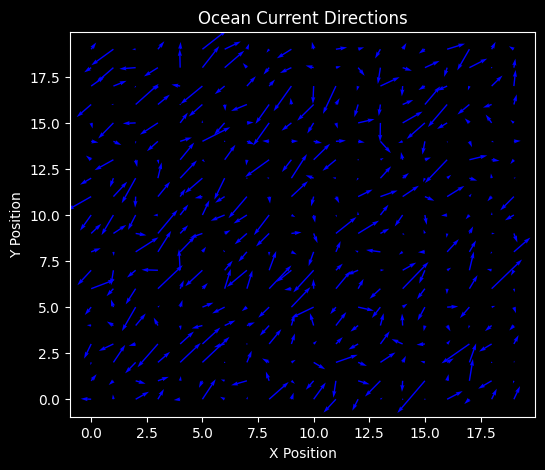

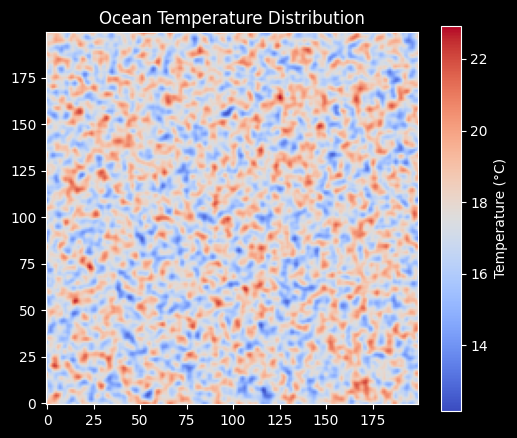

Simulation complete.


In [4]:
import numpy as np
import dask.array as da
import matplotlib.pyplot as plt

grid_size = 200
TIME_STEPS = 100
chunk_size = (100, 100)

temperature = da.random.uniform(5, 30, size=(grid_size, grid_size), chunks=chunk_size)
u_velocity = da.random.uniform(-1, 1, size=(grid_size, grid_size), chunks=chunk_size)
v_velocity = da.random.uniform(-1, 1, size=(grid_size, grid_size), chunks=chunk_size)
wind = da.random.uniform(-0.5, 0.5, size=(grid_size, grid_size), chunks=chunk_size)

def laplacian(field):
    """Computes the discrete Laplacian of a 2D field using finite differences."""
    lap = (
            np.roll(field, shift=1, axis=0) +
            np.roll(field, shift=-1, axis=0) +
            np.roll(field, shift=1, axis=1) +
            np.roll(field, shift=-1, axis=1) -
            4 * field
    )
    return lap

def update_field(field, wind_field, is_temperature=False, alpha=0.1, beta=0.02):
    if is_temperature:
        return field + 0.01 * laplacian(field)
    else:
        return field + alpha * laplacian(field) + beta * wind_field

def update_ocean_dask(u, v, temperature, wind):
    u_new = da.map_overlap(
        update_field, u, wind, is_temperature=False,
        depth=1, boundary='periodic', dtype=float
    )

    v_new = da.map_overlap(
        update_field, v, wind, is_temperature=False,
        depth=1, boundary='periodic', dtype=float
    )

    temperature_new = da.map_overlap(
        update_field, temperature, wind, is_temperature=True,
        depth=1, boundary='periodic', dtype=float
    )

    return u_new, v_new, temperature_new

# Run the simulation
for t in range(TIME_STEPS):
    u_velocity, v_velocity, temperature = update_ocean_dask(u_velocity, v_velocity, temperature, wind)
    if t % 10 == 0 or t == TIME_STEPS - 1:
        print(f"Time Step {t}: Computing ocean currents...")

print("Evaluating Dask computation graph...")
u_computed, v_computed, temp_computed = da.compute(u_velocity, v_velocity, temperature)

plt.figure(figsize=(6, 5))
plt.quiver(u_computed[::10, ::10], v_computed[::10, ::10], color="blue")
plt.title("Ocean Current Directions")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(temp_computed, cmap='coolwarm', origin='lower')
plt.colorbar(label="Temperature (°C)")
plt.title("Ocean Temperature Distribution")
plt.show()

print("Simulation complete.")

### Benchmarking

#### With Dask

In [3]:
def benchmark_dask(start_chunk, end_chunk, chunk_step, n_runs=3):
    grid_size = 200  # Fixed grid size
    time_steps = 100 # Fixed time steps

    # Generate the list of chunk dimensions to test
    chunk_dims = list(range(start_chunk, end_chunk + 1, chunk_step))
    avg_times = []

    print(f"Starting benchmark (Grid: {grid_size}x{grid_size}, Runs per chunk: {n_runs})")
    print("-" * 50)

    for c in chunk_dims:
        chunk_size = (c, c)
        print(f"Testing chunk size: {chunk_size}...")

        run_times = []
        for run in range(n_runs):
            # 1. Initialize fields with current chunk size
            temperature = da.random.uniform(5, 30, size=(grid_size, grid_size), chunks=chunk_size)
            u_velocity = da.random.uniform(-1, 1, size=(grid_size, grid_size), chunks=chunk_size)
            v_velocity = da.random.uniform(-1, 1, size=(grid_size, grid_size), chunks=chunk_size)
            wind = da.random.uniform(-0.5, 0.5, size=(grid_size, grid_size), chunks=chunk_size)

            # 2. Build the Dask computation graph
            for _ in range(time_steps):
                u_velocity, v_velocity, temperature = update_ocean_dask(u_velocity, v_velocity, temperature, wind)

            # 3. Time the parallel evaluation
            start_time = time.time()
            da.compute(u_velocity, v_velocity, temperature)
            end_time = time.time()

            run_times.append(end_time - start_time)

        # Calculate the average execution time across the runs
        avg_time = sum(run_times) / n_runs
        avg_times.append(avg_time)
        print(f"  -> Average Execution Time: {avg_time:.4f} seconds\n")

    plt.figure(figsize=(8, 5))
    plt.plot(chunk_dims, avg_times, marker='o', linestyle='-', color='b', linewidth=2)

    plt.title(f"Dask Simulation Performance vs. Chunk Size\n(Grid: {grid_size}x{grid_size}, Averaged over {n_runs} runs)")
    plt.xlabel("Chunk Dimension (c x c)")
    plt.ylabel("Average Execution Time (Seconds)")
    plt.grid(True, linestyle='--', alpha=0.7)

    # Optional: Highlight the fastest chunk size
    min_time = min(avg_times)
    best_chunk = chunk_dims[avg_times.index(min_time)]
    plt.axvline(x=best_chunk, color='r', linestyle='--', alpha=0.5, label=f"Fastest: {best_chunk}x{best_chunk}")
    plt.legend()

    plt.tight_layout()
    plt.show()

Starting benchmark (Grid: 200x200, Runs per chunk: 3)
--------------------------------------------------
Testing chunk size: (50, 50)...
  -> Average Execution Time: 18.3368 seconds

Testing chunk size: (100, 100)...
  -> Average Execution Time: 6.4628 seconds

Testing chunk size: (150, 150)...
  -> Average Execution Time: 5.9153 seconds

Testing chunk size: (200, 200)...
  -> Average Execution Time: 3.9857 seconds



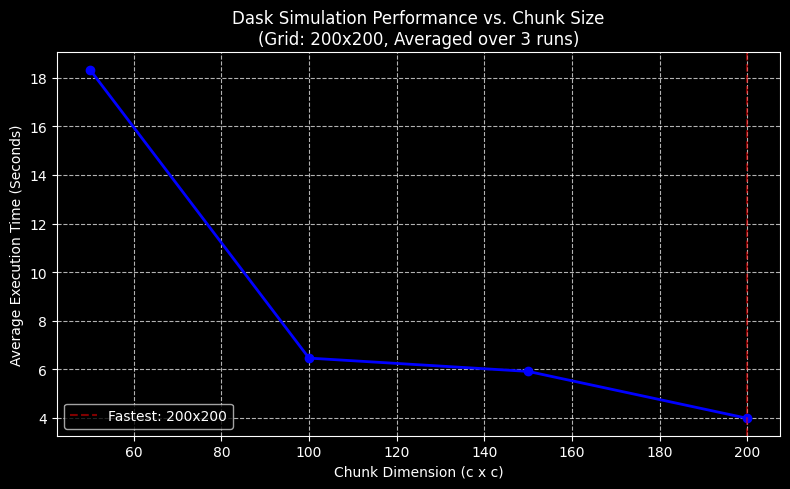

In [20]:
benchmark_dask(50, 200, 50)

#### Serial

In [24]:
def benchmark_serial(grid_size=200, time_steps=100, n_runs=25):
    print(f"Starting serial benchmark (Grid: {grid_size}x{grid_size}, Steps: {time_steps}, Runs: {n_runs})")
    print("-" * 60)

    run_times = []

    for run in range(n_runs):
        # 1. Initialize arrays using NumPy
        temperature = np.random.uniform(5, 30, size=(grid_size, grid_size))
        u_velocity = np.random.uniform(-1, 1, size=(grid_size, grid_size))
        v_velocity = np.random.uniform(-1, 1, size=(grid_size, grid_size))
        wind = np.random.uniform(-0.5, 0.5, size=(grid_size, grid_size))

        # 2. Time the simulation loop
        start_time = time.time()

        for _ in range(time_steps):
            u_velocity, v_velocity, temperature = update_ocean(u_velocity, v_velocity, temperature, wind)

        end_time = time.time()

        # 3. Record elapsed time
        elapsed = end_time - start_time
        run_times.append(elapsed)
        print(f"  Run {run + 1}/{n_runs} completed in {elapsed:.4f} seconds")

    # Calculate and output average
    avg_time = sum(run_times) / n_runs
    print("-" * 60)
    print(f"Average Serial Execution Time: {avg_time:.4f} seconds")

    return avg_time

In [25]:
benchmark_serial()

Starting serial benchmark (Grid: 200x200, Steps: 100, Runs: 25)
------------------------------------------------------------
  Run 1/25 completed in 0.0411 seconds
  Run 2/25 completed in 0.0342 seconds
  Run 3/25 completed in 0.0378 seconds
  Run 4/25 completed in 0.0379 seconds
  Run 5/25 completed in 0.0375 seconds
  Run 6/25 completed in 0.0452 seconds
  Run 7/25 completed in 0.0366 seconds
  Run 8/25 completed in 0.0351 seconds
  Run 9/25 completed in 0.0336 seconds
  Run 10/25 completed in 0.0358 seconds
  Run 11/25 completed in 0.0396 seconds
  Run 12/25 completed in 0.0433 seconds
  Run 13/25 completed in 0.0388 seconds
  Run 14/25 completed in 0.0351 seconds
  Run 15/25 completed in 0.0342 seconds
  Run 16/25 completed in 0.0361 seconds
  Run 17/25 completed in 0.0362 seconds
  Run 18/25 completed in 0.0399 seconds
  Run 19/25 completed in 0.0401 seconds
  Run 20/25 completed in 0.0341 seconds
  Run 21/25 completed in 0.0326 seconds
  Run 22/25 completed in 0.0332 seconds
  Ru

0.0372406005859375

We can see that the serial version strangely takes far less time than the dask version, this might possibly due to the overhead for creating multiple processes and the grid size is not large enough to see the difference.

## Task B.2: Monitor Performance with dask.distributed the Dask Dashboard

In [1]:
from dask.distributed import Client

client = Client()

In [3]:
def run_with_size(chunk_size=100, grid_size=200, time_steps=100):
    temperature = da.random.uniform(5, 30, size=(grid_size, grid_size), chunks=chunk_size)
    u_velocity = da.random.uniform(-1, 1, size=(grid_size, grid_size), chunks=chunk_size)
    v_velocity = da.random.uniform(-1, 1, size=(grid_size, grid_size), chunks=chunk_size)
    wind = da.random.uniform(-0.5, 0.5, size=(grid_size, grid_size), chunks=chunk_size)

    # 2. Build the Dask computation graph
    for _ in range(time_steps):
        u_velocity, v_velocity, temperature = update_ocean_dask(u_velocity, v_velocity, temperature, wind)

    da.compute(u_velocity, v_velocity, temperature)

#### Task B2.2: Experiment with Different Chunk Sizes

##### 200x200

In [6]:
run_with_size(200)

![asm4_taskb.2.2_200.png](asm4_taskb.2.2_200.png)

##### 100x100

In [7]:
run_with_size(100)

![asm4_taskb.2.2_100.png](asm4_taskb.2.2_100.png)

##### 50x50

In [6]:
run_with_size(50)

![asm4_taskb.2.2_50.png](asm4_taskb.2.2_50.png)

### Task B2.3

> How well-balanced were the worker loads?

The worker CPU loads and memory usage are very balanced, below is a screenshot from the dashboard and we can see basically the usage is uniformly distributed among the 5 workers (50x50).

![asm4_taskb.2.3_uniform.png](asm4_taskb.2.3_uniform.png)

> Did any worker run out of memory?

No, none of the workers ran out of memory in my experiments.

> Was there idle time or task queuing?

Yes from the Task Stream above, we can see that there are blank spaces between the tasks, which indicates the worker thread was idling at those moments.

### Task B2.4 - Save the flow information on the grid in VTK files and use Paraview for the visualization.

In [16]:
if not hasattr(np, 'float_'):
    np.float_ = np.float64

import pyvtk
import os

def save_to_vtk(filename, u, v, temp):
    ny, nx = u.shape

    temp_flat = temp.flatten().tolist()
    u_flat = u.flatten()
    v_flat = v.flatten()
    z_flat = np.zeros_like(u_flat)

    vectors = list(zip(u_flat, v_flat, z_flat))

    vtk = pyvtk.VtkData(
        pyvtk.StructuredPoints([nx, ny, 1]),
        pyvtk.PointData(
            pyvtk.Scalars(temp_flat, name="Temperature", lookup_table="default"),
            pyvtk.Vectors(vectors, name="Velocity")
        ),
        'Ocean Simulation Step'
    )

    vtk.tofile(filename, 'ascii')

def build_animation():
    grid_size = 200
    time_steps = 100
    chunk_size = (100, 100)
    output_dir = "ocean_vtk"

    temperature = da.random.uniform(5, 30, size=(grid_size, grid_size), chunks=chunk_size)
    u_velocity = da.random.uniform(-1, 1, size=(grid_size, grid_size), chunks=chunk_size)
    v_velocity = da.random.uniform(-1, 1, size=(grid_size, grid_size), chunks=chunk_size)
    wind = da.random.uniform(-0.5, 0.5, size=(grid_size, grid_size), chunks=chunk_size)

    for t in range(time_steps):
        # Update Dask graph
        u_velocity, v_velocity, temperature = update_ocean_dask(u_velocity, v_velocity, temperature, wind)

        # Compute the concrete NumPy arrays for this specific step
        u_comp, v_comp, temp_comp = da.compute(u_velocity, v_velocity, temperature)

        # Save the frame
        filename = os.path.join(output_dir, f"ocean_step_{t:03d}.vtk")
        save_to_vtk(filename, u_comp, v_comp, temp_comp)

        if t % 10 == 0 or t == time_steps - 1:
            print(f"Completed and saved Step {t}/{time_steps-1} -> {filename}")

    print(f"Simulation complete. All {time_steps} files saved in '{output_dir}/'.")

In [17]:
build_animation()

Completed and saved Step 0/99 -> ocean_vtk/ocean_step_000.vtk
Completed and saved Step 10/99 -> ocean_vtk/ocean_step_010.vtk
Completed and saved Step 20/99 -> ocean_vtk/ocean_step_020.vtk
Completed and saved Step 30/99 -> ocean_vtk/ocean_step_030.vtk
Completed and saved Step 40/99 -> ocean_vtk/ocean_step_040.vtk
Completed and saved Step 50/99 -> ocean_vtk/ocean_step_050.vtk
Completed and saved Step 60/99 -> ocean_vtk/ocean_step_060.vtk
Completed and saved Step 70/99 -> ocean_vtk/ocean_step_070.vtk
Completed and saved Step 80/99 -> ocean_vtk/ocean_step_080.vtk
Completed and saved Step 90/99 -> ocean_vtk/ocean_step_090.vtk
Completed and saved Step 99/99 -> ocean_vtk/ocean_step_099.vtk
Simulation complete. All 100 files saved in 'ocean_vtk/'.


![asm4_taskb.2.4_temp.png](asm4_taskb.2.4_temp.png)
![asm4_taskb.2.4_velocity.png](asm4_taskb.2.4_velocity.png)

# AI Declaration

Bonus Part:
- Task B1:
    - Model: Gemini 3.1 Pro
    - Usage: Generate the benchmark function and beautify the charts
- Generative LLMs are not used in other Bonus Parts